# TCBench: Quick Start

**Goal.** This notebook demonstrates a minimal, end-to-end workflow to evaluate tropical-cyclone (TC) **track** and **intensity** forecasts on the **2023** test year using the TCBench toolbox and local CSV files.  
It loads IBTrACS, loads one or more model track CSVs, runs the evaluation (or loads the corresponding `*_results.csv` if already computed), and renders compact figures and DataFrame previews so that every step is transparent.

**What you’ll see (at a glance):**
- A quick preview (`.head()`) of **IBTrACS** after light preprocessing (e.g., 6-hour grid, 00/12Z inits).  
- A preview of **model track CSVs** (columns & a few rows).  
- A preview of **evaluation outputs** (columns & a few rows) for both deterministic and probabilistic metrics.  
- Simple plots mirroring the figures in the paper for a minimal subset (to keep runtime short).

> This notebook is **self-contained, offline, and anonymized** (relative paths only; no external calls).

### Add-Your-Own Model (One-Minute Setup)

1. Export your model’s TC track forecasts for **2023** (00/12Z inits; 6-hourly leads up to 120 h).  
2. Save as `output/<your_model>.csv` using the schema above.  
3. Re-run the **evaluation** cell—your file will be detected automatically, evaluated (or loaded), and included in the previews and plots.


In [ ]:
# Install requirements into the *current* Jupyter kernel 
%pip install -r requirements.txt

## Load the IBTrACS test set (ground truth)
**IBTrACS** (International Best Track Archive for Climate Stewardship) is the
global reference archive of tropical cyclone “best tracks,” compiled from all
basin warning centers and harmonized by NOAA. It provides a consistent,
time-ordered record of each storm’s location and intensity through its life
cycle. We use IBTrACS as the **ground truth** for verifying model tracks and
intensities.

The file we load here (`data/ibtracs/ibtracs.ALL.list.v04r01.csv`) contains the
global record; in this notebook we subset to **2023** and verify on the
standard **6-hour grid** (00/06/12/18 UTC) with intensities referenced to the
“USA” source used in IBTrACS.

---

### Columns used in ibtracs

| Column        | Type / Units                 | Description                                                                                             | Notes |
|---            |---                           |---                                                                                                      |---|
| `SID`         | string                       | Unique storm identifier within IBTrACS.                                                                 | Stable key used to group track points belonging to the same cyclone. |
| `SEASON`      | integer (year)               | Season year of the storm.                                                                               | We filter to `SEASON == 2023`. |
| `BASIN`       | categorical                  | Basin code (e.g., `NA` North Atlantic, `WP` West Pacific, `EP` East Pacific, `NI` North Indian, `SI` South Indian, `SP` South Pacific). |  |
| `SUBBASIN`    | categorical / string         | Sub-basin code where available.                                                                         | |
| `NAME`        | string                       | Storm name (if assigned).                                                                               |  |
| `ISO_TIME`    | datetime (UTC, ISO-8601)     | Analysis time for this record.                                                                          | Nominally 6-hourly; occasionally higher frequency. Convert with `pd.to_datetime(..., utc=True)` and floor to the hour if needed. |
| `NATURE`      | categorical                  | Storm nature/class (e.g., `TROPICAL`, `SUBTROPICAL`, `EXTRATROPICAL`, `REMNANT LOW`, `DISTURBANCE`).     | |
| `LAT`         | float (degrees)              | Storm center latitude.                                                                                  |  |
| `LON`         | float (degrees)              | Storm center longitude.                                                                                 |  |
| `USA_ATCF_ID` | string                       | ATCF storm identifier from the USA source (e.g., `AL012023`, `WP192023`).                               |  |
| `USA_WIND`    | float (knots)                | **Maximum 1-minute sustained wind** from the USA source at `ISO_TIME`.                                  | Used as ground-truth intensity for wind. Missing values appear as NaN. |
| `USA_PRES`    | float (hPa)                  | **Minimum central pressure** from the USA source at `ISO_TIME`.                                         | Used as ground-truth intensity for pressure. Missing values appear as NaN. |


In [6]:
from utils import toolbox

ibtracs = toolbox.read_hist_track_file(tracks_path="/home/mgomezd1/Downloads/TCBench/data/ibtracs")

ibtracs = ibtracs[ibtracs["ISO_TIME"].dt.year == 2023]
ibtracs.sample(5)

/home/mgomezd1/envs/tcbench/lib/python3.12/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,SID,SEASON,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,USA_ATCF_ID,USA_WIND,USA_PRES
710602,2023271N14144,2023,WP,MM,KOINU,2023-10-06 12:00:00,TS,21.40625,116.3125,WP142023,100,957
709932,2023248N12257,2023,EP,MM,JOVA,2023-09-10 09:00:00,DS,24.00000,233.1875,EP112023,38,1003
705827,2023016S15160,2023,SP,MM,IRENE,2023-01-17 18:00:00,TS,-17.59375,160.7500,SH092023,30,998
706864,2023096S07135,2023,SI,WA,ILSA,2023-04-07 21:00:00,TS,-9.50000,130.1250,SH182023,33,992
707065,2023129N08091,2023,NI,BB,MOCHA,2023-05-15 00:00:00,MX,25.09375,97.8125,IO012023,20,1002


### Evaluate and materialize results (then preview )

This cell runs the **evaluation pipeline** over all model track CSVs found in `outputs/` and
verifies them against **IBTrACS 2023** (`data/ibtracs`). Concretely, it:

1) **Discovers** candidate input files in `outputs/` (e.g., `2023_PANGU.csv`, `2023_aifs.csv`, …).  
2) **Matches** each track to IBTrACS on the standardized 6-hour grid (00/12Z inits, 6–120 h leads).  
3) **Computes metrics** and writes them to disk as `<name>_results.csv`.  
   - Deterministic: track errors (DPE/Along/Cross), intensity errors (AE/SE), etc.  
   - Probabilistic (if ensemble): CRPS variants are added as `*_mean` / `*_std`.  
4) **Generates/refreshes RI files** (`<name>_RI.csv`) so RI plots can be made later.  
5) Returns a couple of convenience objects:
   - `result_paths`: where each results file was written.  
   - `all_cases`: the evaluated `(SID, Initial Time, Valid Time)` pairs (useful for FAIR/coverage).


**Recompute?** By default `recompute=False`, so existing `<name>_results.csv` files are **reused** and
only **new** inputs are computed. Set `recompute=True` if you want to **overwrite** the results.

Below, we print a small random sample of PANGU’s deterministic metrics and GENC's probabilistic ones to show the schema.

In [ ]:
%load_ext autoreload

In [12]:
%autoreload

In [13]:
from evaluate_tracks import evaluate_tracks
import pandas as pd

eval_dir = "/home/mgomezd1/Downloads/TCBench/outputs"
ib_dir = "/home/mgomezd1/Downloads/TCBench/data/ibtracs"

result_paths, result_dfs, all_cases = evaluate_tracks(
    eval_folder=eval_dir,
    ibtracs_tracks_path=ib_dir,
    year=2023,
    select_files=["2023_PANGU.csv"],  # ex: ["2023_PANGU.csv", "2023_GENC.csv"]
    recompute=True,
    only_ri=False,
    exclude_patterns=("RI", "results", "ibtracs"),
    save_results=True,
    return_dataframes=False,
    verbose=True,
)

# Example: preview one model's results
pangu_results_df = pd.read_csv("/home/mgomezd1/Downloads/TCBench/outputs/2023_PANGU_results.csv")
print("Example: PANGU results (Deterministic metrics)")
pangu_results_df.sample(5)

Candidates in '/home/mgomezd1/Downloads/TCBench/outputs': 1 | to compute (recompute=True): 1

Working on 2023_PANGU.csv...
Calculating DPE...
Calculating AE...
Calculating SE...
Calculating CARTE...
Overwriting existing results: /home/mgomezd1/Downloads/TCBench/outputs/2023_PANGU_results.csv
[RI] Recomputing RI file for 2023_PANGU.csv...
Saved RI file: /home/mgomezd1/Downloads/TCBench/outputs/2023_PANGU_RI.csv
Example: PANGU results (Deterministic metrics)


,SID,Initial Time,Valid Time,wind max,pressure min,lat,lon,DPE_GCD,AE_wind,AE_pressure,SE_wind,SE_pressure,Along_TE,Cross_TE,DPE_cart
4483,2023234N18128,2023-08-22 12:00:00,2023-08-27 00:00:00,29.777763,995.8164,18.50,123.75,210.560737,85.222237,53.8164,7262.829728,2896.204909,47.612904,145.070232,152.683859
3517,2023218N25145,2023-08-11 00:00:00,2023-08-16 00:00:00,27.796290,997.9374,39.00,136.75,149.789324,17.203710,15.9374,295.967639,254.000719,0.000000,91.476247,91.476247
7522,2023261N13248,2023-09-20 00:00:00,2023-09-21 06:00:00,28.288995,1004.4450,16.25,234.00,125.815609,16.711005,4.4450,279.257685,19.758025,0.000000,84.849309,84.849309
2144,2023202N13240,2023-07-16 12:00:00,2023-07-19 18:00:00,21.025273,1009.0370,12.75,246.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9182,2023292N11063,2023-10-18 12:00:00,2023-10-21 12:00:00,31.604856,1001.4540,11.00,56.50,104.395148,38.395144,17.4540,1474.187107,304.642116,0.000000,110.205977,110.205977


In [15]:
print("Example: GENC results (Probabilistic metrics)")
genc_results_df = pd.read_csv("/home/mgomezd1/Downloads/TCBench/outputs/2023_GENC_results.csv")
genc_results_df.sample(5)

Example: GENC results (Probabilistic metrics)


,SID,Initial Time,Valid Time,lat,lon,wind max,pressure min,Hour,DPE_GCD_mean,DPE_GCD_std,...,DPE_cart_mean,Along_TE_std,Cross_TE_std,DPE_cart_std,CRPS_vmax_mean,CRPS_pmin_mean,CRPS_vmax_std,CRPS_pmin_std,CRPS_haversine_mean,CRPS_haversine_std
6307,2023234N19154,2023-08-26 00:00:00,2023-08-28 06:00:00,39.38,145.11,74.1,978.5,54.0,116.353536,52.958788,...,147.831004,52.838457,24.690921,51.327853,14.759755,1.605143,NaN,NaN,71.354367,NaN
7021,2023247N20130,2023-09-06 00:00:00,2023-09-07 18:00:00,34.25,140.61,50.4,995.6,42.0,286.262783,65.522639,...,186.741170,48.732860,36.456850,39.018351,6.199347,1.902776,NaN,NaN,237.866869,NaN
7739,2023258N14318,2023-09-18 12:00:00,2023-09-21 00:00:00,38.00,308.75,81.5,972.6,60.0,55.049537,34.796875,...,101.413172,57.423755,81.339906,77.286537,0.858612,0.699918,NaN,NaN,16.776774,NaN
8644,2023271N14144,2023-09-30 12:00:00,2023-10-04 18:00:00,23.63,121.38,65.9,984.6,102.0,215.370059,114.561889,...,175.789776,29.040763,81.356531,77.144953,42.119102,39.200327,NaN,NaN,131.802625,NaN
2530,2023179N15256,2023-07-02 00:00:00,2023-07-02 18:00:00,19.88,242.63,39.1,1002.7,18.0,30.499708,13.982832,...,40.491789,17.145376,30.378337,26.489511,12.548050,1.404433,NaN,NaN,12.877849,NaN


Loading IBTrACS from /home/mgomezd1/Downloads/TCBench/data/ibtracs …
IBTrACS 2023: 6,256 rows, 89 storms.
Loading persistence from /home/mgomezd1/Downloads/TCBench/outputs/persistence_results.csv …
Plotting RAW comparison …


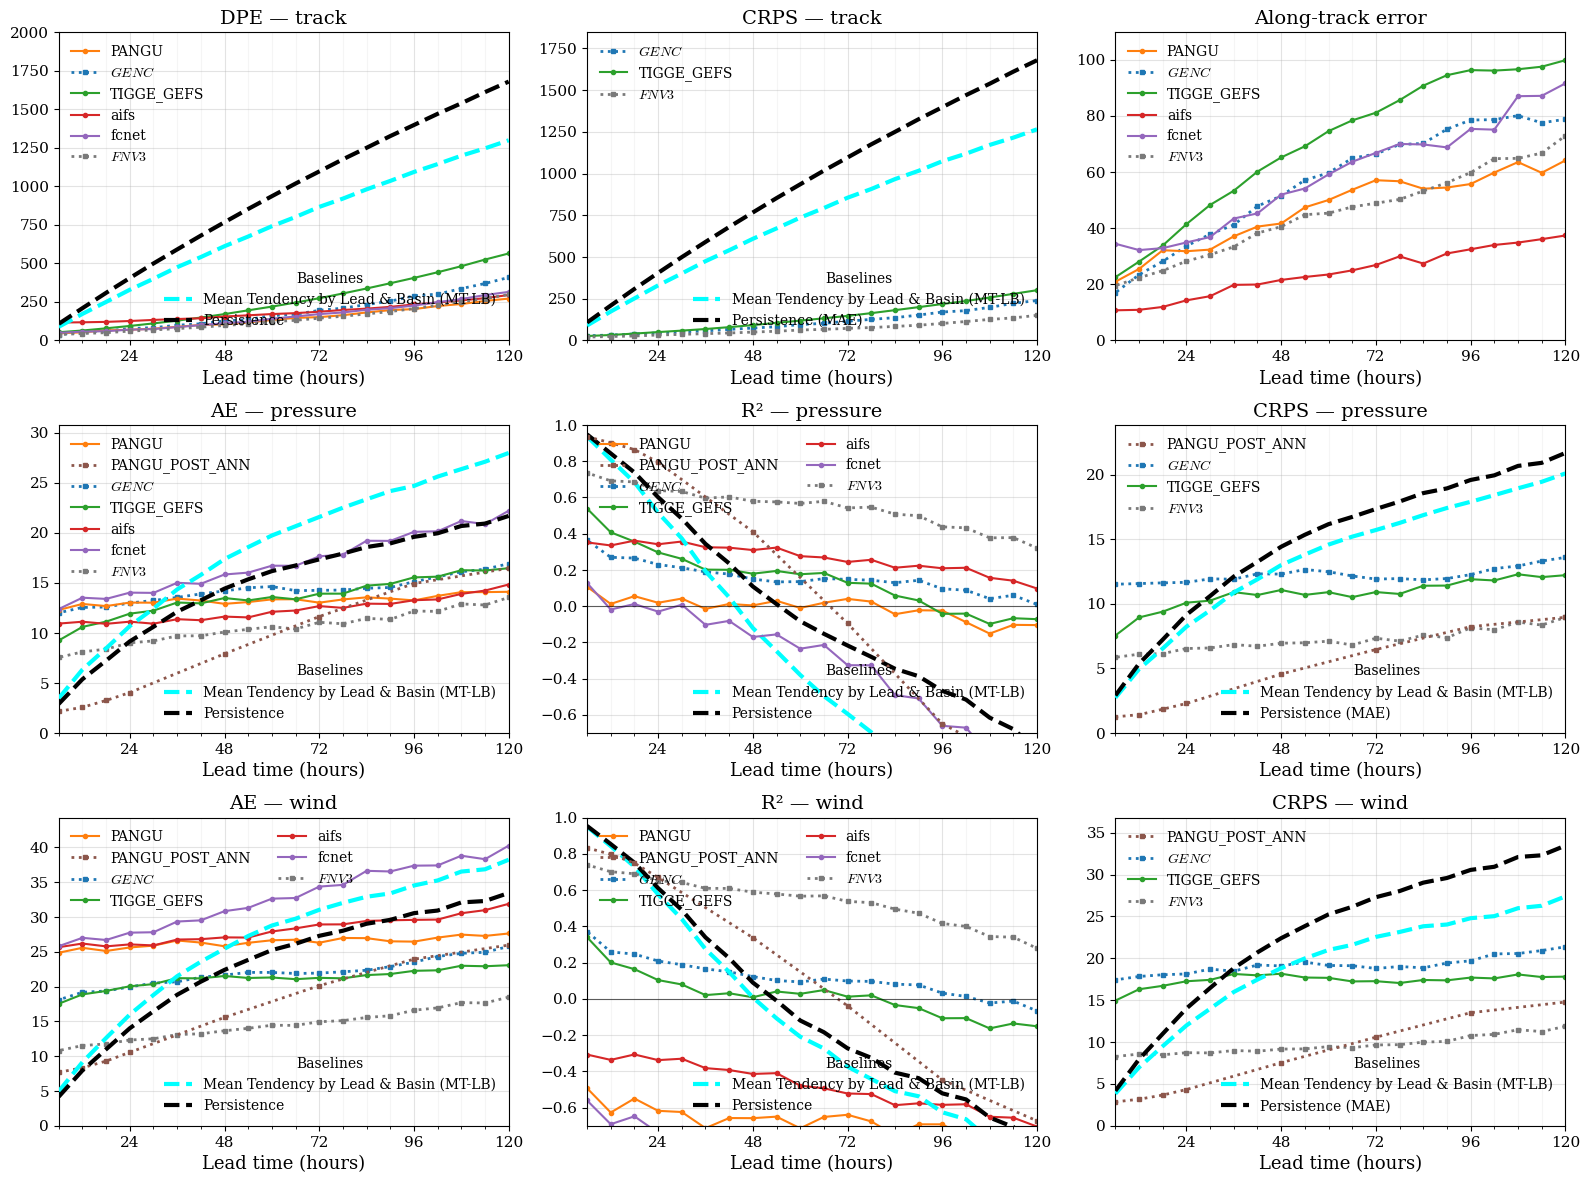

Plotting FAIR comparison …


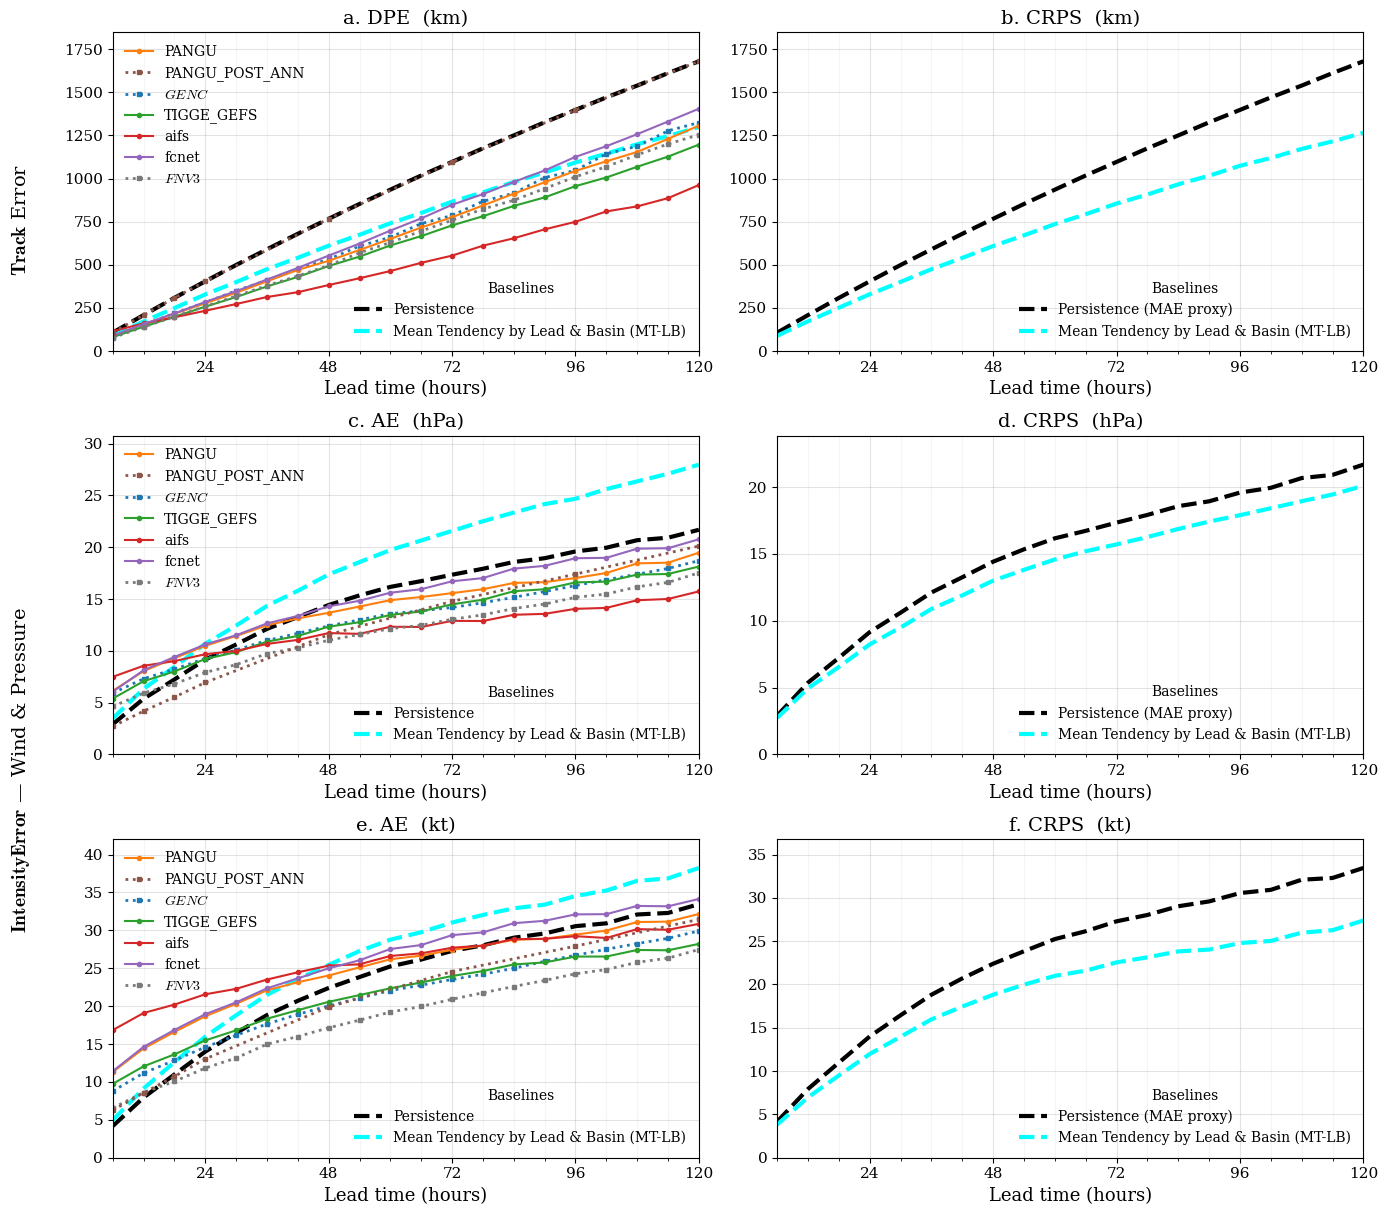

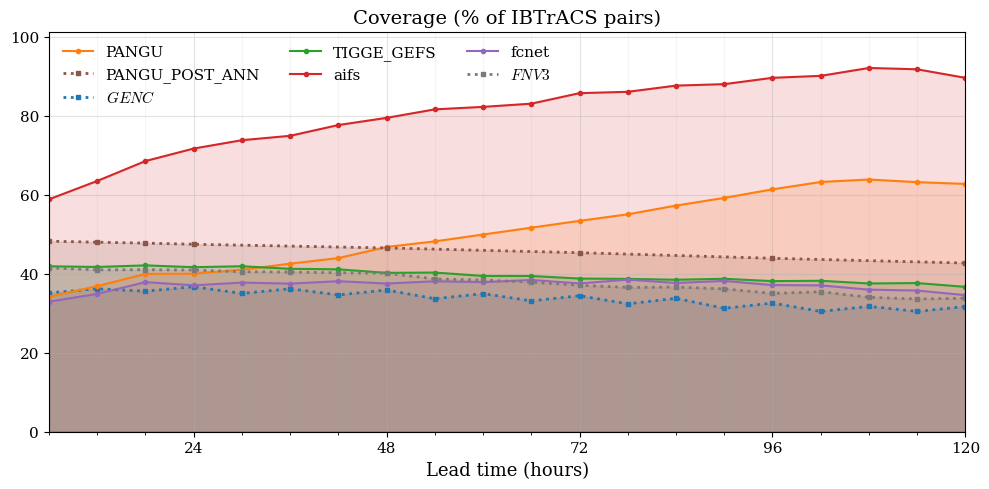

Plotting TIERED comparison …


/home/mgomezd1/repos/tcbench/dev/plot_errors_cli.py:1366: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.


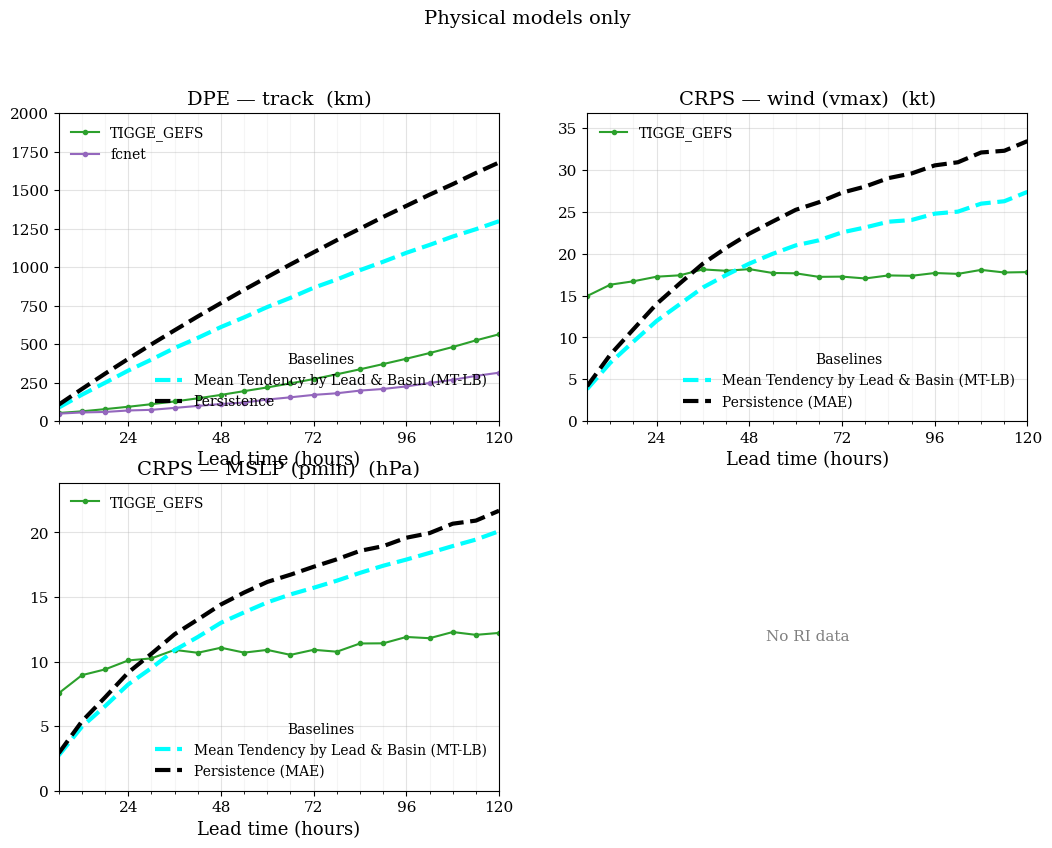

/home/mgomezd1/envs/tcbench/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/home/mgomezd1/repos/tcbench/dev/plot_errors_cli.py:1366: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.


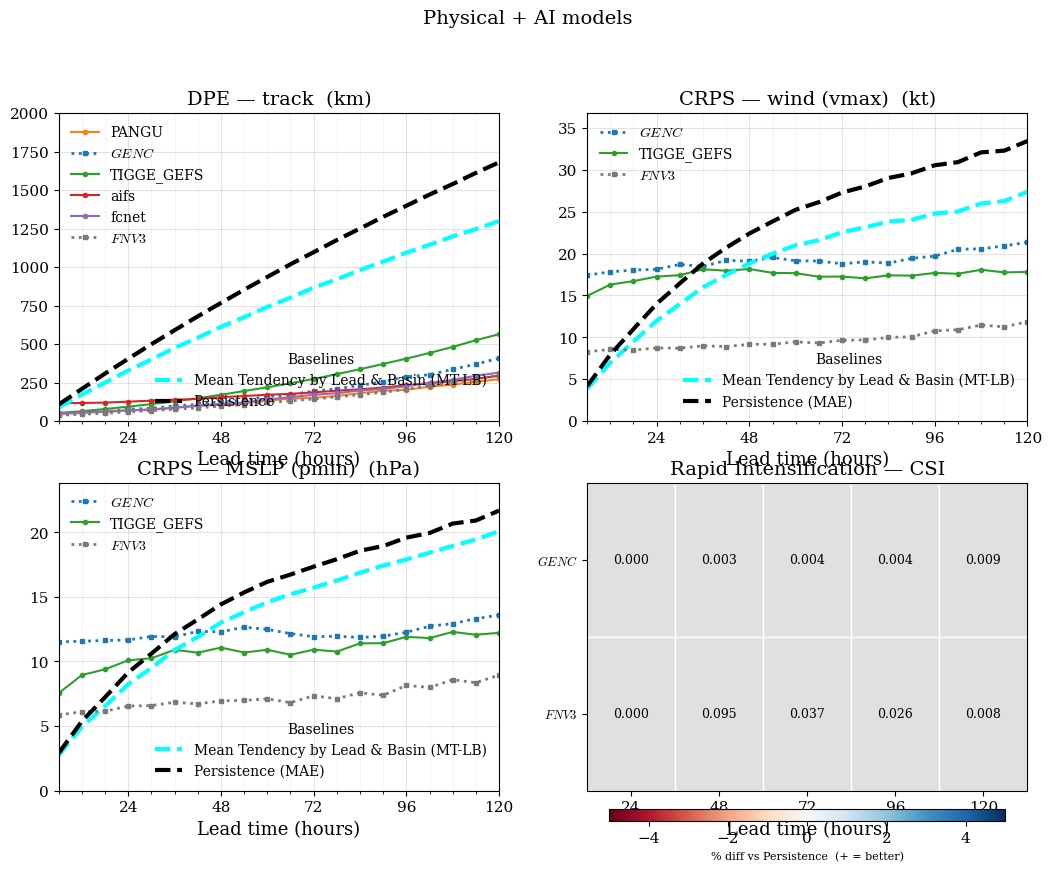

/home/mgomezd1/envs/tcbench/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/home/mgomezd1/repos/tcbench/dev/plot_errors_cli.py:1366: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.


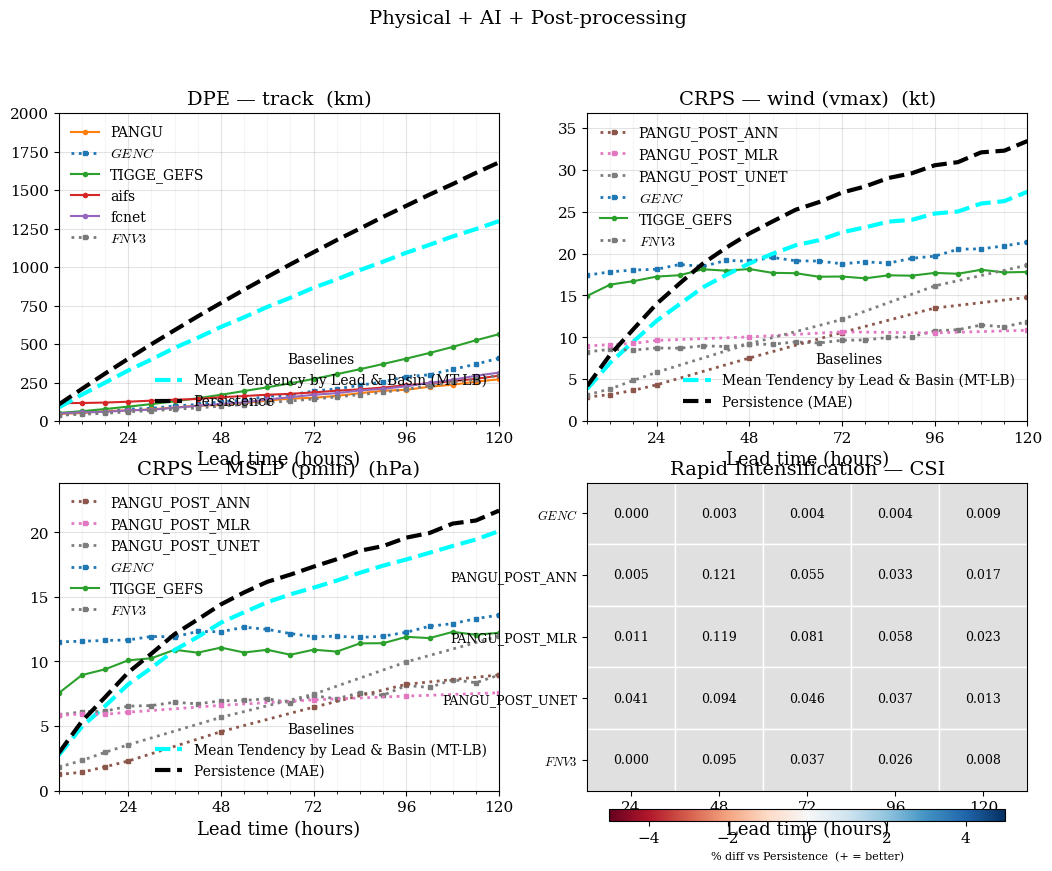

In [24]:
%run -i plot_errors_cli.py \
    --eval-dir "/home/mgomezd1/Downloads/TCBench/outputs" \
    --ibtracs-dir "/home/mgomezd1/Downloads/TCBench/data/ibtracs" \
    --figure raw fair tiered \
    --output TCBench_2023 --format pdf --no-save